## Import Modules

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns

from utils import *

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

DATASETS = ['statlog', 'chd', 'framingham', 'heart', 'stroke']
MODEL_NAMES = ['logreg', 'knn', 'decisiontree', 'svm', 'naivebayes',
               'randomforest', 'xgb', 'lightgbm']

## Baseline Test

In [2]:
baseline_results = []

for ds in DATASETS:
    df_test = get_test(ds)
    _, scaler = get_preprocessed(ds, ds)
    
    # scale test set
    y_test = df_test['target']
    X_test_raw = df_test.drop(columns=['target'])
    try:
        X_test = pd.DataFrame(
            scaler.transform(X_test_raw),
            columns=X_test_raw.columns,
            index=X_test_raw.index
        )
    except Exception:
        X_test = X_test_raw
    
    for model_name in MODEL_NAMES:
        model = load_baseline_model(ds, model_name)
        metrics = evaluate_on_test(model, X_test, y_test)
        baseline_results.append({
            'dataset': ds,
            'model': model_name,
            'train_source': 'baseline',
            **metrics
        })

df_baseline = pd.DataFrame(baseline_results)
df_baseline.head()

,dataset,model,train_source,accuracy,f1_weighted,f1_macro,recall_minority
0,statlog,logreg,baseline,0.444444,0.273504,0.307692,1.000000
1,statlog,knn,baseline,0.555556,0.396825,0.357143,0.000000
2,statlog,decisiontree,baseline,0.481481,0.468519,0.475000,0.666667
3,statlog,svm,baseline,0.555556,0.396825,0.357143,0.000000
4,statlog,naivebayes,baseline,0.555556,0.396825,0.357143,0.000000


## Concat Test

In [3]:
CONCAT_CONFIGS = [
    # 2-dataset combinations
    ('statlog_chd_union',               ['statlog', 'chd']),
    ('statlog_chd_intersection',         ['statlog', 'chd']),
    ('statlog_framingham_union',         ['statlog', 'framingham']),
    ('statlog_framingham_intersection',  ['statlog', 'framingham']),
    ('statlog_heart_union',              ['statlog', 'heart']),
    ('statlog_heart_intersection',       ['statlog', 'heart']),
    ('statlog_stroke_union',             ['statlog', 'stroke']),
    ('statlog_stroke_intersection',      ['statlog', 'stroke']),
    ('chd_framingham_union',             ['chd', 'framingham']),
    ('chd_framingham_intersection',      ['chd', 'framingham']),
    ('chd_heart_union',                  ['chd', 'heart']),
    ('chd_heart_intersection',           ['chd', 'heart']),
    ('chd_stroke_union',                 ['chd', 'stroke']),
    ('chd_stroke_intersection',          ['chd', 'stroke']),
    ('framingham_heart_union',           ['framingham', 'heart']),
    ('framingham_heart_intersection',    ['framingham', 'heart']),
    ('framingham_stroke_union',          ['framingham', 'stroke']),
    ('framingham_stroke_intersection',   ['framingham', 'stroke']),
    ('heart_stroke_union',               ['heart', 'stroke']),
    ('heart_stroke_intersection',        ['heart', 'stroke']),
    # 3-dataset combinations
    ('statlog_chd_framingham_union',           ['statlog', 'chd', 'framingham']),
    ('statlog_chd_framingham_intersection',    ['statlog', 'chd', 'framingham']),
    ('statlog_chd_heart_union',                ['statlog', 'chd', 'heart']),
    ('statlog_chd_heart_intersection',         ['statlog', 'chd', 'heart']),
    ('statlog_chd_stroke_union',               ['statlog', 'chd', 'stroke']),
    ('statlog_chd_stroke_intersection',        ['statlog', 'chd', 'stroke']),
    ('statlog_framingham_heart_union',         ['statlog', 'framingham', 'heart']),
    ('statlog_framingham_heart_intersection',  ['statlog', 'framingham', 'heart']),
    ('statlog_framingham_stroke_union',        ['statlog', 'framingham', 'stroke']),
    ('statlog_framingham_stroke_intersection', ['statlog', 'framingham', 'stroke']),
    ('statlog_heart_stroke_union',             ['statlog', 'heart', 'stroke']),
    ('statlog_heart_stroke_intersection',      ['statlog', 'heart', 'stroke']),
    ('chd_framingham_heart_union',             ['chd', 'framingham', 'heart']),
    ('chd_framingham_heart_intersection',      ['chd', 'framingham', 'heart']),
    ('chd_framingham_stroke_union',            ['chd', 'framingham', 'stroke']),
    ('chd_framingham_stroke_intersection',     ['chd', 'framingham', 'stroke']),
    ('chd_heart_stroke_union',                 ['chd', 'heart', 'stroke']),
    ('chd_heart_stroke_intersection',          ['chd', 'heart', 'stroke']),
    ('framingham_heart_stroke_union',          ['framingham', 'heart', 'stroke']),
    ('framingham_heart_stroke_intersection',   ['framingham', 'heart', 'stroke']),
]

In [4]:
concat_results = []

for concat_name, members in CONCAT_CONFIGS:
    df_concat, scaler_concat = get_preprocessed_combined(concat_name, concat_name)
    
    for member_ds in members:
        df_test_member = get_test(member_ds)
        # Align test set columns to concat training columns
        X_test, y_test = align_test_to_train(df_test_member, df_concat, scaler_concat)
        
        for model_name in MODEL_NAMES:
            model = load_concat_model(concat_name, model_name)
            metrics = evaluate_on_test(model, X_test, y_test)
            concat_results.append({
                'concat_dataset': concat_name,
                'dataset': member_ds,
                'model': model_name,
                'train_source': 'concat',
                'combination_type': 'union' if concat_name.endswith('union') else 'intersection',
                'n_datasets': len(members),
                **metrics
            })

df_concat_results = pd.DataFrame(concat_results)
df_concat_results.head()

,concat_dataset,dataset,model,train_source,combination_type,n_datasets,accuracy,f1_weighted,f1_macro,recall_minority
0,statlog_chd_union,statlog,logreg,concat,union,2,0.444444,0.273504,0.307692,1.00
1,statlog_chd_union,statlog,knn,concat,union,2,0.537037,0.388220,0.349398,0.00
2,statlog_chd_union,statlog,decisiontree,concat,union,2,0.685185,0.685725,0.685077,0.75
3,statlog_chd_union,statlog,svm,concat,union,2,0.444444,0.273504,0.307692,1.00
4,statlog_chd_union,statlog,naivebayes,concat,union,2,0.444444,0.273504,0.307692,1.00


## Comparison


In [5]:
METRICS = ['accuracy', 'f1_weighted', 'f1_macro', 'recall_minority']

df_best_concat = (df_concat_results
    .groupby(['dataset', 'model', 'combination_type', 'n_datasets'])[METRICS]
    .mean().reset_index()
)

# Baseline per (dataset, model)
df_base = df_baseline[['dataset', 'model'] + METRICS].copy()
df_base.columns = ['dataset', 'model'] + [f'baseline_{m}' for m in METRICS]

# Merge
df_compare = df_best_concat.merge(df_base, on=['dataset', 'model'], how='left')

# Delta = Concat - Baseline
for m in METRICS:
    df_compare[f'delta_{m}'] = df_compare[m] - df_compare[f'baseline_{m}']

df_compare['generalization_gain'] = df_compare['delta_f1_macro']
df_compare.sort_values('generalization_gain', ascending=False).head(20)

,dataset,model,combination_type,n_datasets,accuracy,f1_weighted,f1_macro,recall_minority,baseline_accuracy,baseline_f1_weighted,baseline_f1_macro,baseline_recall_minority,delta_accuracy,delta_f1_weighted,delta_f1_macro,delta_recall_minority,generalization_gain
31,chd,xgb,union,3,0.629032,0.564996,0.496134,0.354167,0.344086,0.176172,0.256000,1.000000,0.284946,0.388824,0.240134,-0.645833,0.240134
30,chd,xgb,union,2,0.577957,0.481604,0.440094,0.445312,0.344086,0.176172,0.256000,1.000000,0.233871,0.305432,0.184094,-0.554688,0.184094
23,chd,randomforest,union,3,0.593190,0.493445,0.416694,0.276042,0.344086,0.176172,0.256000,1.000000,0.249104,0.317273,0.160694,-0.723958,0.160694
10,chd,lightgbm,union,2,0.502688,0.420637,0.414608,0.664062,0.344086,0.176172,0.256000,1.000000,0.158602,0.244465,0.158608,-0.335938,0.158608
11,chd,lightgbm,union,3,0.555556,0.448779,0.407749,0.484375,0.344086,0.176172,0.256000,1.000000,0.211470,0.272607,0.151749,-0.515625,0.151749
49,framingham,naivebayes,intersection,3,0.500000,0.409125,0.295438,0.500000,0.162736,0.061509,0.145627,1.000000,0.337264,0.347616,0.149811,-0.500000,0.149811
17,chd,naivebayes,intersection,3,0.560932,0.437870,0.399319,0.453125,0.344086,0.176172,0.256000,1.000000,0.216846,0.261697,0.143319,-0.546875,0.143319
29,chd,xgb,intersection,3,0.591398,0.473233,0.397584,0.239583,0.344086,0.176172,0.256000,1.000000,0.247312,0.297061,0.141584,-0.760417,0.141584
27,chd,svm,union,3,0.655914,0.519620,0.396104,0.000000,0.344086,0.176172,0.256000,1.000000,0.311828,0.343448,0.140104,-1.000000,0.140104
133,stroke,knn,intersection,3,0.276419,0.265998,0.179431,0.790000,0.057730,0.022053,0.056211,1.000000,0.218689,0.243945,0.123220,-0.210000,0.123220


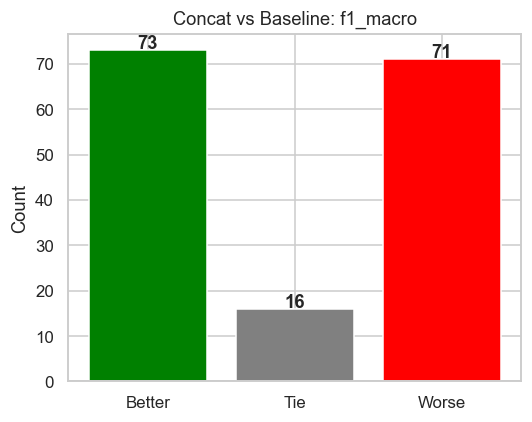

In [6]:
total = len(df_compare)
wins = (df_compare['generalization_gain'] > 0).sum()
ties = (df_compare['generalization_gain'] == 0).sum()
losses = (df_compare['generalization_gain'] < 0).sum()

fig, ax = plt.subplots(figsize=(5, 4))

ax.bar(['Better', 'Tie', 'Worse'], [wins, ties, losses],
       color=['green', 'grey', 'red'])
ax.set_title('Concat vs Baseline: f1_macro')
ax.set_ylabel('Count')
for i, v in enumerate([wins, ties, losses]):
    ax.text(i, v + 0.3, str(v), ha='center', fontweight='bold')
    
plt.tight_layout()
plt.savefig('result/images/winrate.png', dpi=150, bbox_inches='tight')
plt.show()

C:\Users\USER\AppData\Local\Temp\ipykernel_3572\812543942.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


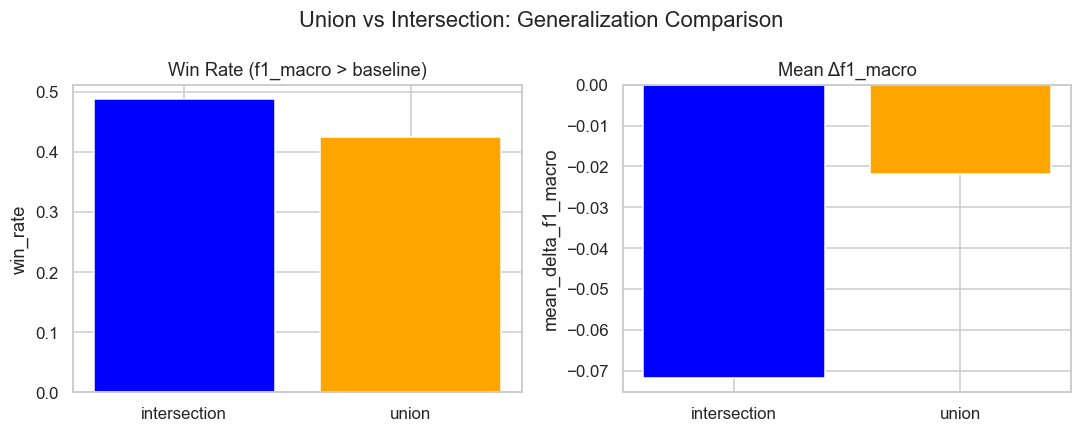

In [7]:
winrate_by_type = (
    df_compare.groupby('combination_type')
    .apply(lambda g: pd.Series({
        'win_rate':  (g['generalization_gain'] > 0).mean(),
        'mean_delta_f1_macro': g['generalization_gain'].mean(),
        'mean_delta_recall_minority': g['delta_recall_minority'].mean(),
        'count': len(g)
    })).reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, col, title in zip(axes,
                           ['win_rate', 'mean_delta_f1_macro'],
                           ['Win Rate (f1_macro > baseline)', 'Mean Δf1_macro']):
    colors = ['blue', 'orange']
    ax.bar(winrate_by_type['combination_type'], winrate_by_type[col], color=colors)
    ax.set_title(title)
    ax.set_ylabel(col)
plt.suptitle('Union vs Intersection: Generalization Comparison')
plt.tight_layout()
plt.savefig('result/images/union_vs_intersection.png', dpi=150, bbox_inches='tight')
plt.show()

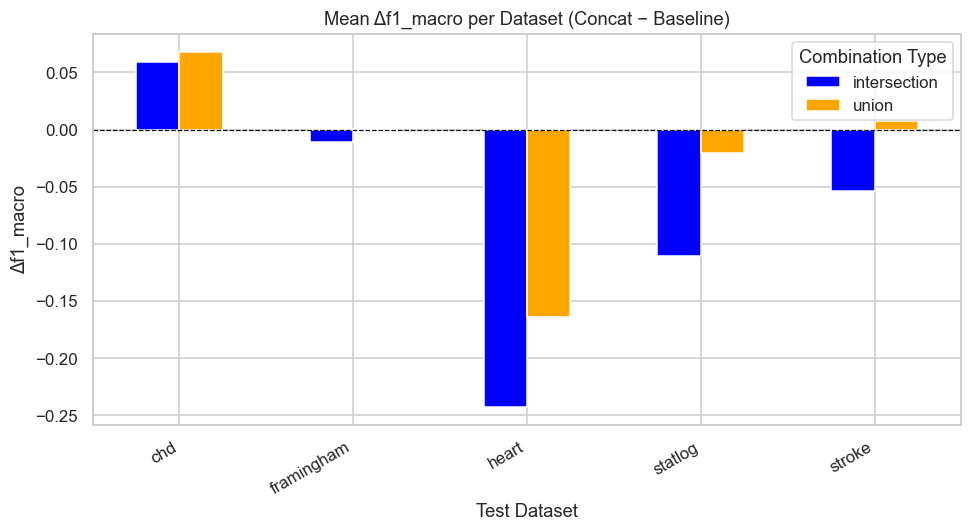

In [8]:
delta_by_ds = (
    df_compare.groupby(['dataset', 'combination_type'])['delta_f1_macro']
    .mean()
    .reset_index()
    .pivot(index='dataset', columns='combination_type', values='delta_f1_macro')
)

fig, ax = plt.subplots(figsize=(9, 5))
delta_by_ds.plot(kind='bar', ax=ax, color=['blue', 'orange'], edgecolor='white')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Mean Δf1_macro per Dataset (Concat − Baseline)')
ax.set_ylabel('Δf1_macro')
ax.set_xlabel('Test Dataset')
ax.legend(title='Combination Type')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('result/images/delta_f1_per_dataset.png', dpi=150, bbox_inches='tight')
plt.show()

## Recall Minority (Disease Detection)

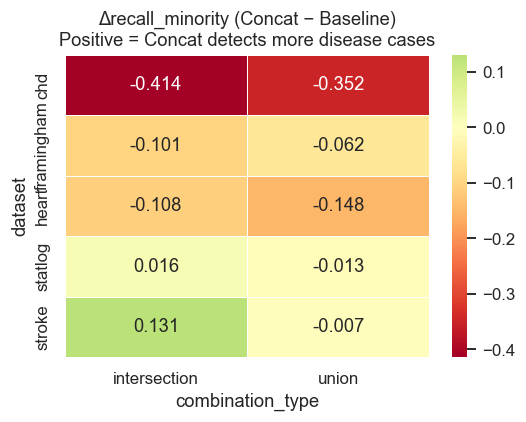

In [9]:
# Heatmap: Δrecall_minority across datasets × combination types
heat_data = (
    df_compare.groupby(['dataset', 'combination_type'])['delta_recall_minority']
    .mean()
    .reset_index()
    .pivot(index='dataset', columns='combination_type', values='delta_recall_minority')
)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(heat_data, annot=True, fmt='.3f', cmap='RdYlGn',
            center=0, linewidths=0.5, ax=ax)
ax.set_title('Δrecall_minority (Concat − Baseline)\nPositive = Concat detects more disease cases')
plt.tight_layout()
plt.savefig('result/images/recall_minority_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## Export


In [10]:
df_baseline.to_csv('result/eval_baseline.csv', index=False)
df_concat_results.to_csv('result/eval_concat.csv', index=False)
df_compare.to_csv('result/eval_comparison.csv', index=False)

- Winrate: Concat Win 73 Lose 71
- Union vs Intersection - both win rate < 50% และ mean Δf1_macro < 0
- Per-dataset
    - chd — ดีขึ้น
    - framingham — แทบไม่เปลี่ยน
    - heart, statlog, stroke — แย่ลง

- Recall minority
ส่วนใหญ่ < 0 แปลว่า concat ทำให้ตรวจจับผู้ป่วยได้แย่ลง ยกเว้น stroke (intersection) ที่ > 0

```การ concat dataset ไม่ได้ช่วย generalization โดยรวม และในบาง dataset กลับทำให้แย่ลง เนื่องจาก feature distribution ที่ต่างกันทำให้ model สับสน```